# Composite laminate shell (GLARE-style fiber-metal laminate)

This example builds a layered `Shell` from a `Laminate` stacking sequence. The
laminate is a GLARE-style fiber-metal laminate: aluminium face sheets with two
glass-fiber/epoxy (GFRP) plies in a 0/90 cross-ply core.

The `Laminate` owns the through-thickness integration (one Simpson rule per
layer) and precomputes the classical lamination theory `ABD` matrices, the
transverse shear stiffness, and the mass integrals.

In [1]:
import torch

from torchfem import Laminate, Shell
from torchfem.materials import (
    IsotropicElasticityPlaneStress,
    OrthotropicElasticityPlaneStress,
)
from torchfem.mesh import rect_tri

torch.set_default_dtype(torch.float64)

## Materials and stacking sequence

In [2]:
# Glass-fiber reinforced polymer ply (plane stress, with transverse shear)
gfrp = OrthotropicElasticityPlaneStress(
    E_1=54000.0, E_2=9400.0, nu_12=0.33, G_12=5500.0, G_13=5500.0, G_23=3000.0,
    rho=1.8e-9,
)

# Aluminium face sheet (isotropic plane stress)
alu = IsotropicElasticityPlaneStress(E=72000.0, nu=0.33, rho=2.7e-9)

# GLARE-style layup: Al / 0 deg GFRP / 90 deg GFRP / Al
layup = Laminate(
    materials=[alu, gfrp, gfrp, alu],
    thicknesses=[0.3, 0.125, 0.125, 0.3],
    angles=[0.0, 0.0, torch.pi / 2, 0.0],
)
layup

<torch-fem laminate (4 layers, 12 integration points)>

## Precomputed ABD matrices

The `Laminate` exposes the classical lamination theory stiffness matrices `A`
(extensional), `B` (bending-extension coupling), and `D` (bending). They are
computed once and cached.

Although the metal face sheets are placed symmetrically, the 0/90 GFRP core is
**not** mirror-symmetric about the mid-plane, so this layup exhibits a small but
nonzero coupling matrix `B` (membrane loads induce bending and vice versa).

In [3]:
A, B, D = layup.vectorize(1).abd
torch.set_printoptions(precision=2, sci_mode=True)
print('A =', A[0])
print('B =', B[0])
print('D =', D[0])

A = tensor([[ 5.66e+04,  1.68e+04, -3.51e-14],
        [ 1.68e+04,  5.66e+04, -3.13e-13],
        [-3.51e-14, -3.13e-13,  1.76e+04]])
B = tensor([[-3.55e+02,  0.00e+00, -2.19e-15],
        [ 0.00e+00,  3.55e+02, -1.96e-14],
        [-2.19e-15, -1.96e-14,  0.00e+00]])
D = tensor([[ 4.07e+03,  1.33e+03, -1.83e-16],
        [ 1.33e+03,  4.07e+03, -1.63e-15],
        [-1.83e-16, -1.63e-15,  1.36e+03]])


## Model setup

A rectangular plate clamped at one edge with a transverse tip load.

In [4]:
L, W = 100.0, 20.0

nodes, elements = rect_tri(21, 5, L, W, variant='zigzag')
nodes = torch.hstack([nodes, torch.zeros((len(nodes), 1))])

plate = Shell(nodes, elements, layup)

# Clamp the x = 0 edge (all 6 dofs)
clamped = nodes[:, 0] < 1e-6
plate.constraints[clamped] = True

# Distribute a transverse tip load over the x = L edge
tip = nodes[:, 0] > (L - 1e-6)
plate.forces[tip, 2] = 5.0 / int(tip.sum())

## Solve

In [5]:
u, f, sigma, _, _ = plate.solve(aggregate_integration_points=False)

print(f'Total laminate thickness: {plate.thickness[0]:.3f}')
print(f'Number of through-thickness stations: {plate.n_z}')
print(f'Tip deflection |u_z|: {u[:, 2].abs().max():.4f}')

Total laminate thickness: 0.850
Number of through-thickness stations: 12
Tip deflection |u_z|: 22.4502


## Through-thickness stresses

With `aggregate_integration_points=False`, `sigma` keeps one entry per
through-thickness station. The stations are ordered bottom-to-top, grouped by
layer (`n_simpson` stations per layer). Below we report the in-plane stress at
the bottom-most and top-most stations.

In [6]:
sigma_bottom = sigma[0]
sigma_top = sigma[-1]
print('max |sigma_xx| (bottom Al ply):', sigma_bottom[:, 0, 0].abs().max().item())
print('max |sigma_xx| (top Al ply):   ', sigma_top[:, 0, 0].abs().max().item())

max |sigma_xx| (bottom Al ply): 219.44278011683892
max |sigma_xx| (top Al ply):    220.12645098282914


## Visualize displacement

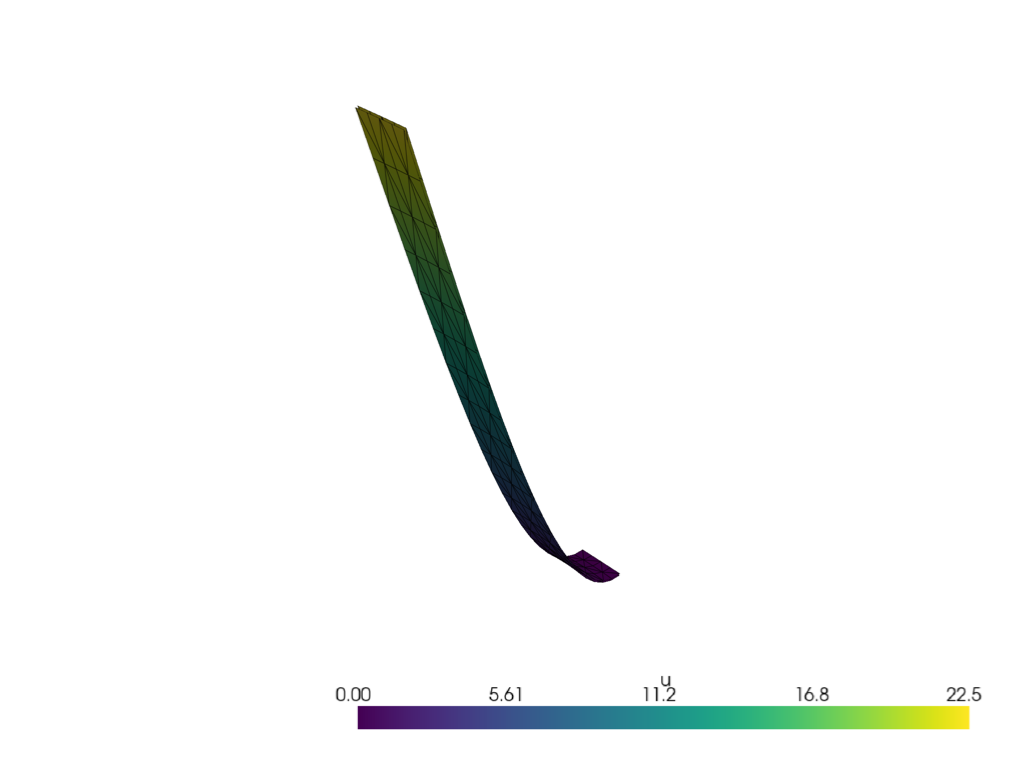

In [7]:
from IPython.display import Image

plate.plot(
    10.0 * u[:, 0:3],
    node_property={'u': torch.linalg.norm(u[:, 0:3], dim=1)},
    thickness=True,
    screenshot='laminate_displacement.png',
)
Image('laminate_displacement.png')